# Lab 2C — Students Dataset EDA
---
Using the Kaggle Students Performance dataset complete the following tasks:

## Tasks
- Task 1: Load the CSV file into a Pandas DataFrame and print its shape and column names
- Task 2: Run `df.describe()` and identify the subject with the highest average score
- Task 3: Use `df.isnull().sum()` to check for any missing values in the dataset
- Task 4: Create a histogram of math scores using `Matplotlib` — _add a title and axis labels_
- Task 5: Use `Seaborn` to plot a scatter chart of reading vs. writing scores — color by gender
- Task 6: Find the average math score grouped by parental education 


**Dataset**: [Students_Academic_Performance](https://www.kaggle.com/dataset/sadiajavedd/students-academic-performance-dataset)

In [21]:
# Import the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data loading and Inspection

In [30]:
# Load CSV fiie

df = pd.read_csv('./StudentsPerformance.csv')

# Display the first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [23]:
# Shape and Column names

print(f"Shape: {df.shape}\n")
print(f"Column Names:\n {df.columns}")

Shape: (1000, 8)

Column Names:
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')


- The dataset contains **1,000 observations (rows)** and **8 features (columns)**.
- Each feature represents a variable describing the student's background or academic performance, which can be used to analyze factors associated with student achievement.

In [24]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


Reading has the highest average score (approximately **69 points**), followed by Writing (68 points) and Mathematics (66 points).

In [25]:
# Check for missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There are no missing values in the dataset.

In [35]:
# Fix Columns by replacing the spaces with underscores.
df.columns = df.columns.str.replace(" ", "_")
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## EDA

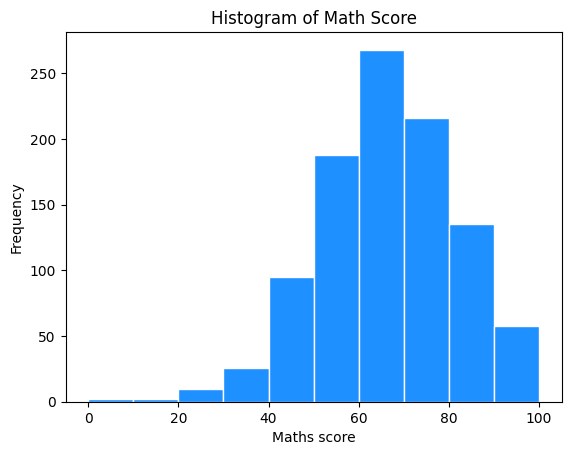

In [43]:
# Histogram of Maths Scores using matplotlib

# Create Histogram
plt.hist(
    x=df['math_score'], 
    bins=10, 
    edgecolor='w',
    color='dodgerblue'
    )

# Add context labels
plt.title("Histogram of Math Score", )
plt.xlabel("Maths score")
plt.ylabel("Frequency")

# Display the plot
plt.show()

## Observations

- The distribution of mathematics scores is slightly left-skewed (negatively skewed), indicating that a few students scored much lower than the majority.
- Most students scored between **60 and 80 marks**, with the highest concentration of scores falling between **60 and 70**.
- The **60–70** score range has the highest frequency, containing over **250 students**, making it the modal class.
- Relatively few students scored below **50 marks**, suggesting that low scores are uncommon.
- The number of students scoring above **90 marks** is also relatively small, indicating that very high scores are less frequent.
- Overall, the distribution suggests that most students achieved **average to above-average performance**, with only a small proportion obtaining very low or very high scores.

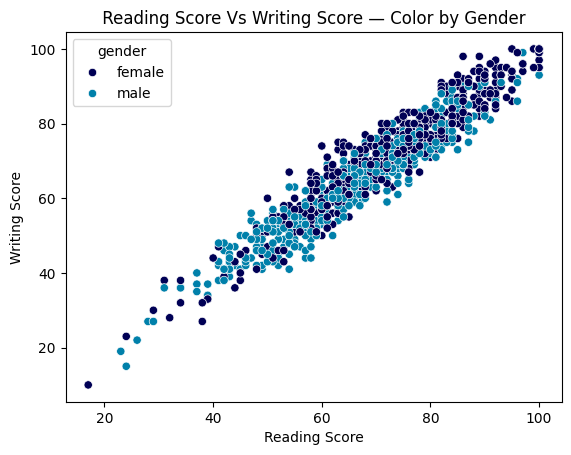

In [28]:
# Scatter chart of reading vs. writing scores — color by gender

sns.scatterplot(
    data=df,
    x='reading_score',
    y='writing_score',
    hue='gender',
    palette='ocean',
    )

plt.title(" Reading Score Vs Writing Score — Color by Gender ")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")

plt.show()


## Interpretation
- The scatter plot shows a strong positive linear relationship between reading and writing scores. Children with higher reading scores tend to have  higher writing scores.
- The data points follow an upward-sloping trend and are closely-packed, indicating a strong positive correlation between the two variables.
- The relationship between these variables is consistent across both genders, this follows from the similar pattern of distribution throughout the score range.
- The outliers are few, suggesting that most students follow the general trend.

In [29]:
# Average math score grouped by parental education 

average_math_score = df.groupby('parental_level_of_education')['math_score'].mean().reset_index()
average_math_score

,parental_level_of_education,math_score
0,associate's degree,67.882883
1,bachelor's degree,69.389831
2,high school,62.137755
3,master's degree,69.745763
4,some college,67.128319
5,some high school,63.497207


Average mathematics scores generally increase with higher parental education levels. Students whose parents hold master's and bachelor's degrees have the highest average scores, while those whose parents have a high school or some high school education have the lowest averages. This indicates a positive association between parental education level and students' mathematics performance.

## Summary
---

1. The dataset contains **1,000 observations (rows)** and **8 features (columns)**. These features describe students' demographic characteristics and academic performance indicators that may be associated with their examination scores.

2. Based on the descriptive statistics, **Reading** has the highest average score (approximately **69 points**), followed by **Writing** (68 points) and **Mathematics** (66 points). This suggests that students performed slightly better in reading than in the other subjects.

3. The dataset contains **no missing values**, indicating that the data is complete and does not require imputation or other missing-value treatments before analysis.

4. The histogram of mathematics scores shows that most students achieved **average to above-average scores**, with the highest concentration of scores between **60 and 70 points**. Only a small proportion of students obtained very low or very high scores.

5. The scatter plot of reading and writing scores reveals a **strong positive linear relationship**, indicating that students with higher reading scores generally also achieve higher writing scores. This trend is consistent across both male and female students.

6. Students whose parents have **higher levels of education**, particularly a **master's** or **bachelor's degree**, tend to achieve higher average mathematics scores. This suggests a **positive association** between parental education level and students' mathematics performance, although the analysis does not establish a causal relationship.